## Adding MMP to PyHDD

In [1]:
import numpy as np
import control as ct
import control.matlab as ctm
import plant
import utils
import matplotlib.pyplot as plt
from function_simulation import Function_simulation, Function_simulation_clean
from scipy import signal
from mfmdob_functions import signal_recovery_iir, wave_generator


     ______          _     _  _____    _____   
    (_____ \        | |   | |(____ \  (____ \  
     _____) ) _   _ | |__ | | _   \ \  _   \ \ 
    |  ____/ | | | ||  __)| || |   | || |   | |
    | |      | |_| || |   | || |__/ / | |__/ / 
    |_|       \__  ||_|   |_||_____/  |_____/  
              (____/                            
    
(v0.1.0)


/home/tomlichu/python-control/venv/lib/python3.12/site-packages/scipy/signal/_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


In [2]:
# runs case 2, room temperature with nominal model
sim_result = Function_simulation_clean(
    plant.Sys_Pc_vcm_c2,
    plant.Sys_Pc_pzt_c2,
    utils.get_Sys_Cd_vcm(),
    utils.get_Sys_Fm_vcm(),
    utils.get_Sys_Cd_pzt(),
    utils.get_Sys_Fm_pzt(),
    plant.Ts,
    plant.Mr_f,
    2
)

function_simulation: process 2 sim progress: 99.2%

In [8]:
# parameter cell
Ts = plant.Ts
F_plant = 1/Ts
Mr_f = plant.Mr_f # upsampling by 2
Mr_P = 20
Ts_fast = Ts / Mr_f 
F_fast = 1/Ts_fast
step = int(Mr_P / Mr_f)   # 20/2 = 10, factor for down-sampling from simulation time to fast-sampling time

# MMP settings
L_mmp = 6
a_g = 0.95
F_RECOVER = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200])
F_DIST_ALL = np.array([
    2200, 2937, 3300, 3545, 3980,
    4220, 4380, 5072, 5370, 5850,
    6660, 7670, 9200,
])

# DOB / filtering settings
SUBTRACT_DF_IN_DOB = False  # False => dhat = dp + P_vcm*df; True => dhat ~= dp
HP_ORDER = 4
HP_CUTOFF_HZ = 1000

# Plotting / metrics settings
T_PLOT_START = 0.01
T_PLOT_END = None  # None uses end of signal
T_RMS_START = 0.10
T_FFT_START = 0.01
FFT_XLIM_FULL = (1000, F_fast / 2)
FFT_XLIM_DIST = (2000, 10000)

# Output settings
SAVE_FIGURES = True
FIG_DIR = "plot_result"

print(f"Plant sampling frequency = {F_plant/1000:.1f} kHz")
print(f"Fast/MR-F sampling frequency = {F_fast/1000:.1f} kHz")
print(f"Sparse MMP sampling frequency = {F_fast/L_mmp/1000:.1f} kHz")
print(f"Simulation-to-fast downsample step = {step}")

Plant sampling frequency = 50.4 kHz
Fast/MR-F sampling frequency = 100.8 kHz
Sparse MMP sampling frequency = 16.8 kHz
Simulation-to-fast downsample step = 10


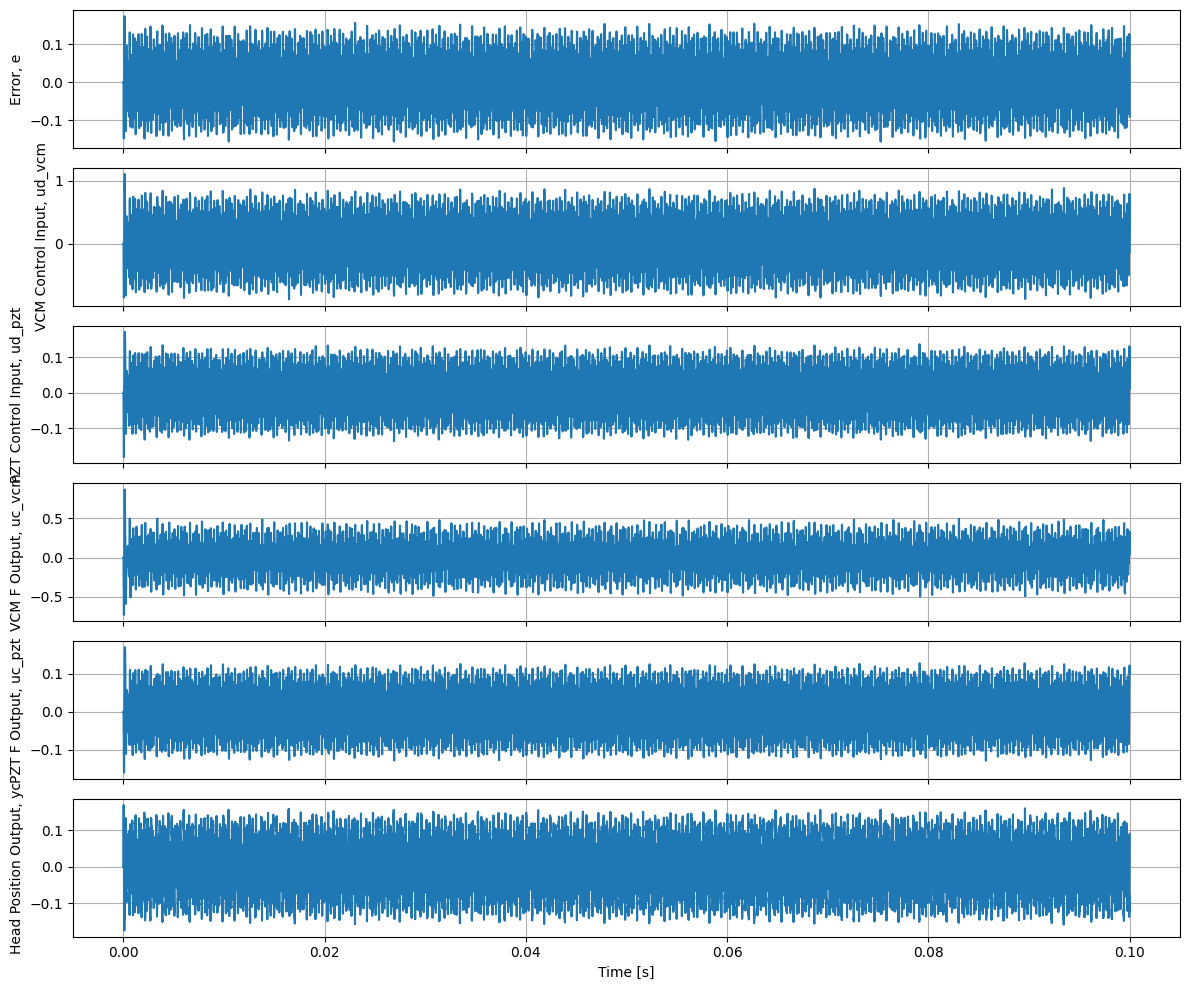

In [9]:
# Plots for various inputs and outputs
t = sim_result['time'] # runs at 1000.8 kHz, simulation time
fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)
axs[0].plot(t, sim_result['e'])
axs[0].set_ylabel('Error, e')
axs[0].grid(True)

axs[1].plot(t, sim_result['ud_vcm'])
axs[1].set_ylabel('VCM Control Input, ud_vcm')
axs[1].grid(True)

axs[2].plot(t, sim_result['ud_pzt'])
axs[2].set_ylabel('PZT Control Input, ud_pzt')
axs[2].grid(True)

axs[3].plot(t, sim_result['uc_vcm'])
axs[3].set_ylabel('VCM F Output, uc_vcm')
axs[3].grid(True)

axs[4].plot(t, sim_result['uc_pzt'])
axs[4].set_ylabel('PZT F Output, uc_pzt')
axs[4].grid(True)

axs[5].plot(t, sim_result['yc'])
axs[5].set_ylabel('Head Position Output, yc')
axs[5].set_xlabel('Time [s]')
axs[5].grid(True)

plt.tight_layout()
plt.show()

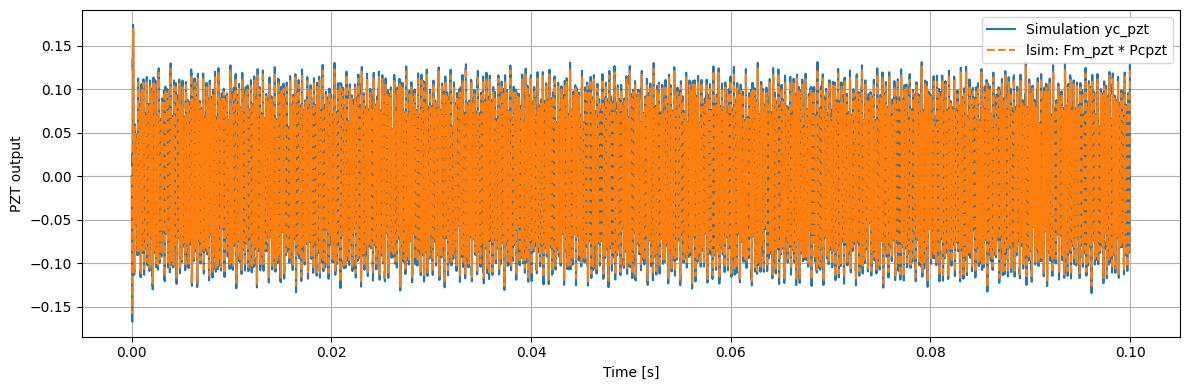

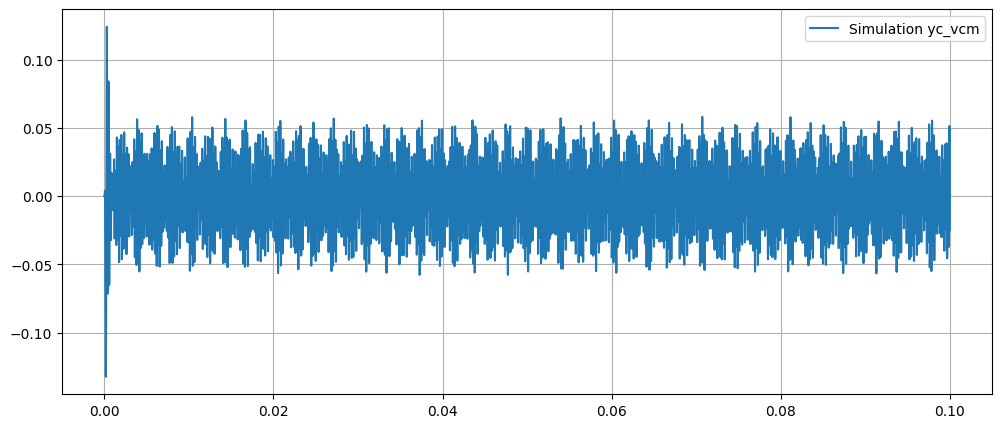

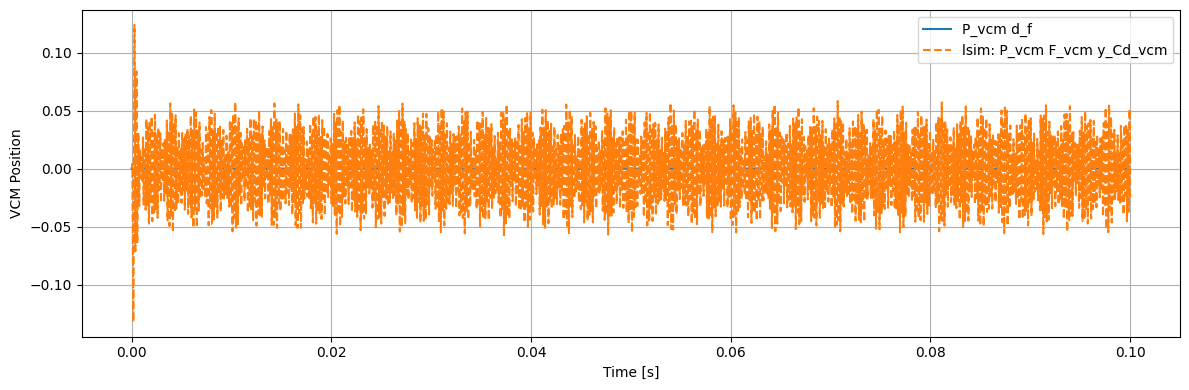

In [10]:
# this cell is used to check that DOB matches the outputs of the simulation

# Filter and plant for PZT and VCM
Sys_Fm_pzt = utils.get_Sys_Fm_pzt()
Sys_Fm_vcm = utils.get_Sys_Fm_vcm()
Sys_Pc_pzt = plant.Sys_Pc_pzt_c2
Sys_Pc_vcm = plant.Sys_Pc_vcm_c2

# get simulation output for plants
yc_vcm_all = np.asarray(sim_result['yc_vcm']).squeeze()
yc_pzt_all = np.asarray(sim_result['yc_pzt']).squeeze()
yc_pzt_fast = yc_pzt_all[::step] # downsampling from simulation output which is 10x faster than fast sampling time
yc_vcm_fast = yc_vcm_all[::step]

# Discretize plant at fast rate
Sys_Pc_pzt_d = ctm.c2d(ctm.ss(Sys_Pc_pzt), Ts_fast) # discretization to fast sampling time
Sys_Pc_vcm_d = ctm.c2d(ctm.ss(Sys_Pc_vcm), Ts_fast)

# Cascade: controller output -> multirate filter -> PZT or VCM plant
Sys_open_pzt = Sys_Pc_pzt_d * Sys_Fm_pzt
Sys_open_vcm = Sys_Pc_vcm_d * Sys_Fm_vcm

# lsim DOB on PZT
u_all = np.asarray(sim_result['ud_pzt']).squeeze()
t_all = np.asarray(sim_result['time']).squeeze()
u_fast = u_all[::step] # downsample input and output
t_fast = t_all[::step]
t_fast = np.arange(len(u_fast)) * Ts_fast
ypzt_lsim, t_lsim, _ = ctm.lsim(Sys_open_pzt, U=u_fast, T=t_fast) # lsim for pzt output

# lsim DOB on VCM, actual output y_vcm = F_vcm * P_vcm * ud_vcm + P_vcm * d_f
u_all = np.asarray(sim_result['ud_vcm']).squeeze()
df_all = np.asarray(sim_result['df']).squeeze() # known disturbance signal from fans
u_fast = u_all[::step] # down sampling
df_fast = df_all[::step]
yvcm_lsim, t_lsim, _ = ctm.lsim(Sys_open_vcm, U=u_fast,T=t_fast) # lsim for F_vcm * P_vcm * ud_vcm
y_df, t_lsim, _ = ctm.lsim(Sys_Pc_vcm_d, U=df_fast, T=t_fast) # lsim for P_vcm * d_f
yvcm_total_lsim = yvcm_lsim + y_df

# plotting
plt.figure(figsize=(12,4))
plt.plot(t, sim_result['yc_pzt'], label='Simulation yc_pzt')
plt.plot(t_lsim, ypzt_lsim, '--', label='lsim: Fm_pzt * Pcpzt')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('PZT output')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(t, sim_result['yc_vcm'], label='Simulation yc_vcm')
# plt.plot(t_lsim, yvcm_total_lsim, '--', label='lsim: Fm_pzt * Pcpzt')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t_fast, y_df, label='P_vcm d_f')
plt.plot(t_lsim, yvcm_lsim, '--', label='lsim: P_vcm F_vcm y_Cd_vcm')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('VCM Position')
plt.tight_layout()
plt.show()

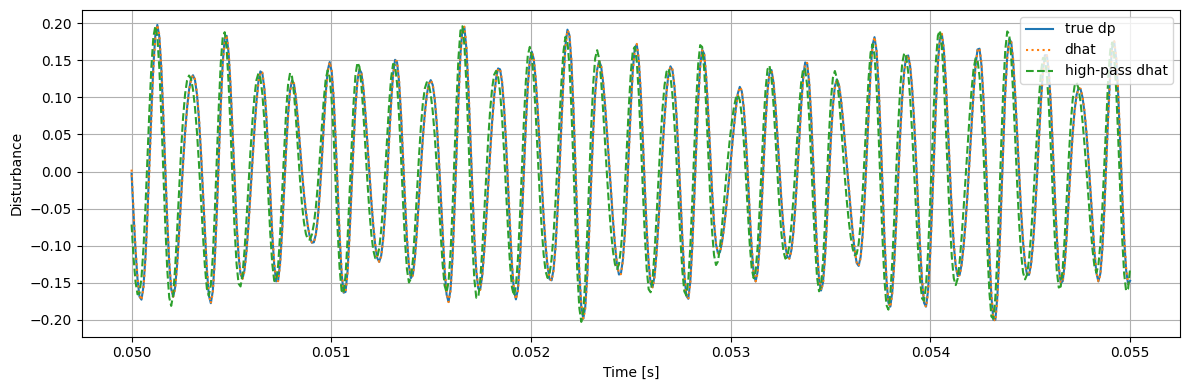

In [11]:
# Systems
Sys_Pc_pzt_d2 = ctm.c2d(ctm.ss(plant.Sys_Pc_pzt_c2), Ts_fast)
Sys_Pc_vcm_d2 = ctm.c2d(ctm.ss(plant.Sys_Pc_vcm_c2), Ts_fast)

yc = np.asarray(sim_result['yc']).squeeze()[::step]
ud_pzt = np.asarray(sim_result['ud_pzt']).squeeze()[::step]
ud_vcm = np.asarray(sim_result['ud_vcm']).squeeze()[::step]
df = np.asarray(sim_result['df']).squeeze()[::step]

t_fast = np.arange(len(yc)) * Ts_fast

# Disturbance observer model outputs
yhat_pzt, _, _ = ctm.lsim(Sys_Pc_pzt_d2 * Sys_Fm_pzt, U=ud_pzt, T=t_fast)
yhat_vcm, _, _ = ctm.lsim(Sys_Pc_vcm_d2 * Sys_Fm_vcm, U=ud_vcm, T=t_fast)
yhat_df,  _, _ = ctm.lsim(Sys_Pc_vcm_d2, U=df, T=t_fast)

# Estimated fan/output disturbance
#dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze() - yhat_df.squeeze()
dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze()

fs_fast = 1 / Ts_fast

"""
# High-pass difference filter: y[n] = x[n] - x[n-1]
b_hp = np.array([1, -1])
a_hp = np.array([1])
"""

# 2nd-order Butterworth high-pass
fc = 1000     # Hz
b_hp, a_hp = signal.butter(
    N=4,
    Wn=fc,
    btype='highpass',
    fs=fs_fast)
dhat_hp = signal.lfilter(b_hp, a_hp, dhat)
dp_true = np.asarray(sim_result['dp']).squeeze()[::step]

t_plot = 0.05
t_end = t_plot + t[-1]*0.05
idx = (t_fast >= t_plot) & (t_fast <= t_end)
plt.figure(figsize=(12,4))
plt.plot(t_fast[idx], dp_true[idx], label='true dp')
plt.plot(t_fast[idx], dhat[idx], ':', label='dhat')
plt.plot(t_fast[idx], dhat_hp[idx], '--', label='high-pass dhat')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.tight_layout()
plt.show()

RMS Error = 4.894425e-06
Relative RMS Error = 0.004%
Relative RMS Error for DOB = 3.723%
Fit = 96.277%


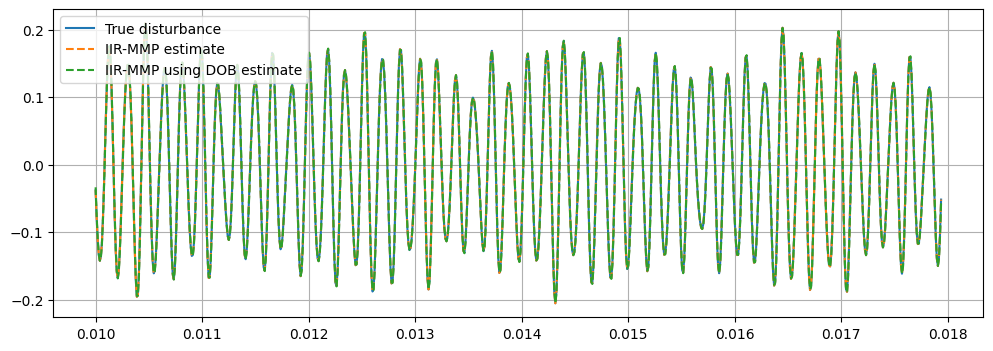

In [26]:
# Fast rate: 100.8 kHz
# Downsample by 6 -> 16.8 kHz
a_g = 0.95
dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze()
 #dhat_fast = np.asarray(dhat_hp).squeeze()
dhat_fast = np.asarray(dhat).squeeze()
dhat_sparse = dhat_fast[::L_mmp]

dp_true_fast = np.asarray(sim_result['dp']).squeeze()[::step] # this is sampling at the fast rate
dp_true_sparse = dp_true_fast[::L_mmp] # actual fan disturbance sampling at 16.8 Hz

# Frequencies to recover
#f_hz = np.array([2200, 2937, 3300, 3545, 3980, 4220, 4380, 5072, 5370, 5850, 6660, 7670, 9200])
#f_hz = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200]) # this is the maximum before instability
f_hz = np.array([5072, 5370, 5850, 7670, 9200])
# IIR-MMP reconstruction
dhat_mmp = signal_recovery_iir(
    input_signal=dhat_sparse,
    f_hz=f_hz,
    t_fs=Ts_fast,
    a_g=a_g,
    L=L_mmp
)

dp_mmp = signal_recovery_iir(
    input_signal=dp_true_sparse,
    f_hz=f_hz,
    t_fs=Ts_fast,
    a_g=a_g,
    L=L_mmp
)

N = min(len(dp_true_fast), len(dp_mmp))
dp_true_fast = dp_true_fast[:N]
dp_mmp = dp_mmp[:N]
dhat_mmp = dhat_mmp[:N]

t = np.arange(N) * Ts_fast

# Match lengths
N = min(len(dhat_fast), len(dhat_mmp))
dhat_fast = dhat_fast[:N]
dhat_mmp = dhat_mmp[:N]

t = np.arange(N) * Ts_fast
t_start = 0.01

idx0 = np.searchsorted(t, t_start)

dp_true_ss = dp_true_fast[idx0:]
dp_mmp_ss = dp_mmp[idx0:]
dhat_mmp_ss = dhat_mmp[idx0:]

rms_err = np.sqrt(
    np.mean(
        (dp_true_ss - dp_mmp_ss)**2
    )
)

rms_err_hat = np.sqrt(
    np.mean(
        (dp_true_ss - dhat_mmp_ss)**2
    )
)

rms_true = np.sqrt(
    np.mean(
        dp_true_ss**2
    )
)

rel_err = rms_err / rms_true
rel_err_hat = rms_err_hat / rms_true

fit = 100 * (1 - rel_err_hat)

print(f"RMS Error = {rms_err:.6e}")
print(f"Relative RMS Error = {100*rel_err:.3f}%")
print(f"Relative RMS Error for DOB = {100*rel_err_hat:.3f}%")
print(f"Fit = {fit:.3f}%")

t_end = 0.01 + Ts*400
idx = (t >= 0.01) & (t <= t_end)

plt.figure(figsize=(12,4))
plt.plot(t[idx], dp_true_fast[idx], label='True disturbance')
plt.plot(t[idx], dp_mmp[idx], '--', label='IIR-MMP estimate')
plt.plot(t[idx], dhat_mmp[idx], '--', label='IIR-MMP using DOB estimate')
plt.grid(True)
plt.legend()
plt.savefig(
    'mmp_output_ss.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

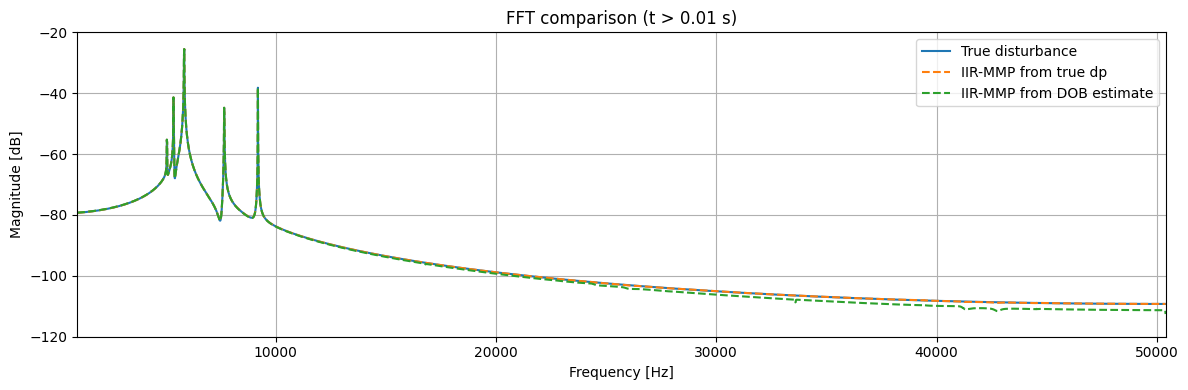

In [18]:
t_start = 0.01

idx0 = np.searchsorted(t, t_start)

# Use only data after 0.01 s
dp_fft = dp_true_fast[idx0:]
dp_mmp_fft = dp_mmp[idx0:]
dhat_mmp_fft = dhat_mmp[idx0:]

# Match lengths
N_fft = min(len(dp_fft), len(dp_mmp_fft), len(dhat_mmp_fft))

dp_fft = dp_fft[:N_fft]
dp_mmp_fft = dp_mmp_fft[:N_fft]
dhat_mmp_fft = dhat_mmp_fft[:N_fft]

# Remove DC
dp_fft = dp_fft - np.mean(dp_fft)
dp_mmp_fft = dp_mmp_fft - np.mean(dp_mmp_fft)
dhat_mmp_fft = dhat_mmp_fft - np.mean(dhat_mmp_fft)

# FFT
freq = np.fft.rfftfreq(N_fft, d=Ts_fast)

Dp = np.fft.rfft(dp_fft)
Dmmp = np.fft.rfft(dp_mmp_fft)
Ddhat = np.fft.rfft(dhat_mmp_fft)

mag_dp_db = 20*np.log10(np.abs(Dp)/N_fft + 1e-30)
mag_mmp_db = 20*np.log10(np.abs(Dmmp)/N_fft + 1e-30)
mag_dhat_db = 20*np.log10(np.abs(Ddhat)/N_fft + 1e-30)

plt.figure(figsize=(12,4))
plt.plot(freq, mag_dp_db, label='True disturbance')
plt.plot(freq, mag_mmp_db, '--', label='IIR-MMP from true dp')
plt.plot(freq, mag_dhat_db, '--', label='IIR-MMP from DOB estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison (t > 0.01 s)')
plt.xlim([1000, 50400])  # adjust as desired
plt.ylim([-120, -20])
plt.tight_layout()
plt.savefig(
    'fft_comparison_full_range.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

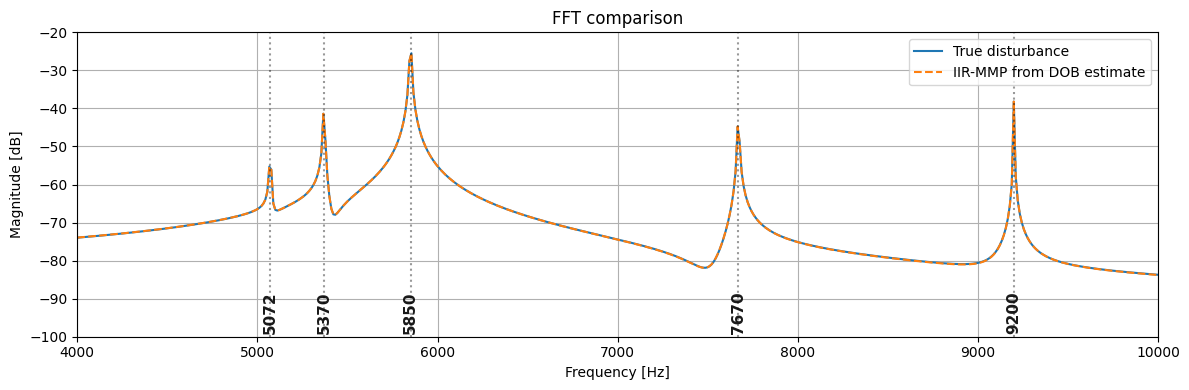

In [21]:
# f_dist = [2200, 2937, 3300, 3545, 3980,4220, 4380, 5072, 5370, 5850,6660, 7670, 9200]
f_dist = [5072, 5370, 5850, 7670, 9200]

plt.figure(figsize=(12,4))

plt.plot(freq, mag_dp_db, label='True disturbance')
#plt.plot(freq, mag_mmp_db, '--', label='IIR-MMP from true dp')
plt.plot(freq, mag_dhat_db, '--', label='IIR-MMP from DOB estimate')

ax = plt.gca()
for f in f_dist:
    ax.axvline(
        x=f,
        color='k',
        linestyle=':',
        alpha=0.4
    )

    ax.text(
        f,
        0.01,                    # 1% above bottom
        f'{f}',
        rotation=90,
        fontsize=11,             # larger text
        fontweight='bold',       # darker/bolder
        color='k',
        alpha=0.9,
        transform=ax.get_xaxis_transform(),
        ha='center',             # centered on frequency
        va='bottom'
    )

plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison')
plt.xlim([4000, 10000])
plt.ylim([-100, -20])

plt.tight_layout()

plt.savefig(
    'fft_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()



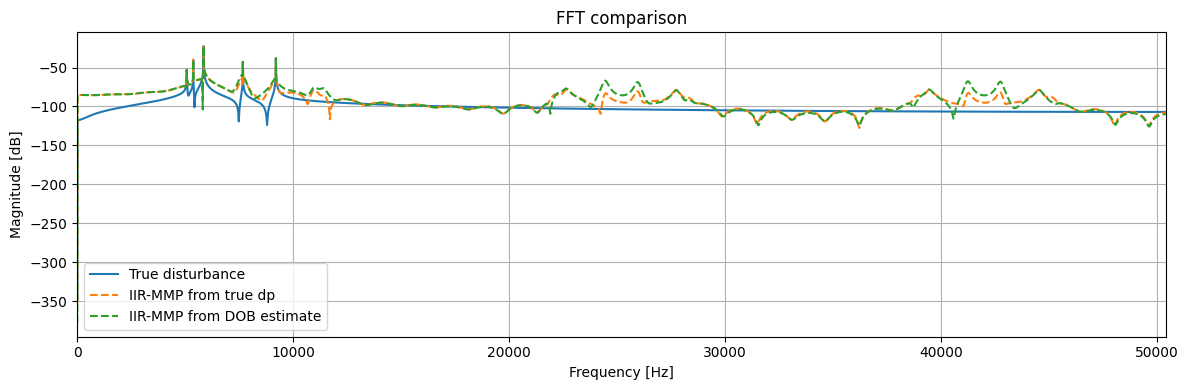

In [23]:
# FFT comparison
N_fft = min(len(dp_true_fast), len(dp_mmp), len(dhat_mmp))

x_true = dp_true_fast[:N_fft]
x_mmp = dp_mmp[:N_fft]
x_dob = dhat_mmp[:N_fft]

# Optional: remove DC before FFT
x_true = x_true - np.mean(x_true)
x_mmp = x_mmp - np.mean(x_mmp)
x_dob = x_dob - np.mean(x_dob)

freq = np.fft.rfftfreq(N_fft, d=Ts_fast)

X_true = np.fft.rfft(x_true)
X_mmp = np.fft.rfft(x_mmp)
X_dob = np.fft.rfft(x_dob)

mag_true_db = 20*np.log10(np.abs(X_true)/N_fft + 1e-30)
mag_mmp_db = 20*np.log10(np.abs(X_mmp)/N_fft + 1e-30)
mag_dob_db = 20*np.log10(np.abs(X_dob)/N_fft + 1e-30)

plt.figure(figsize=(12,4))
plt.plot(freq, mag_true_db, label='True disturbance')
plt.plot(freq, mag_mmp_db, '--', label='IIR-MMP from true dp')
plt.plot(freq, mag_dob_db, '--', label='IIR-MMP from DOB estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison')
plt.xlim([0, fs_fast/2])
plt.tight_layout()
plt.show()

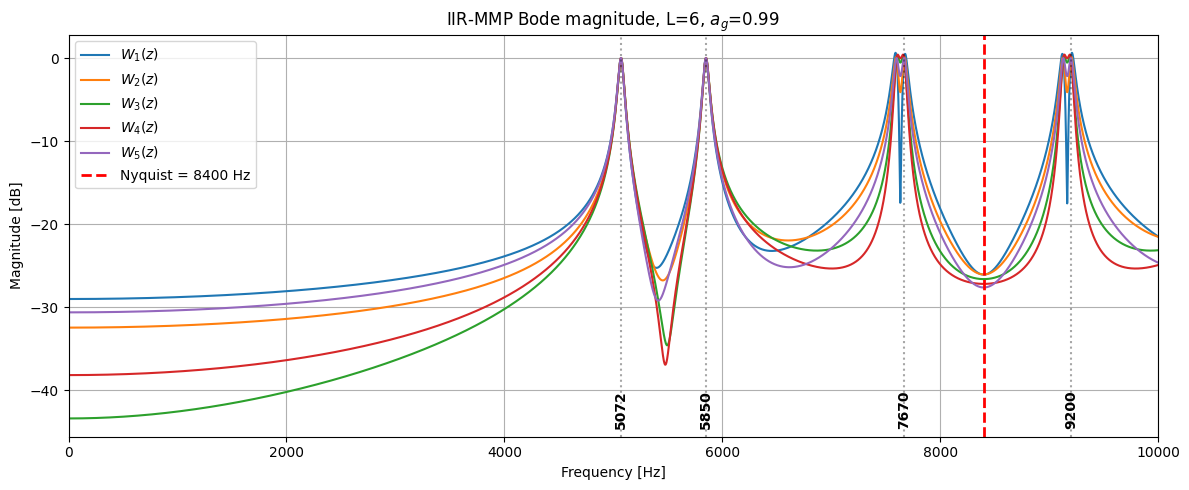

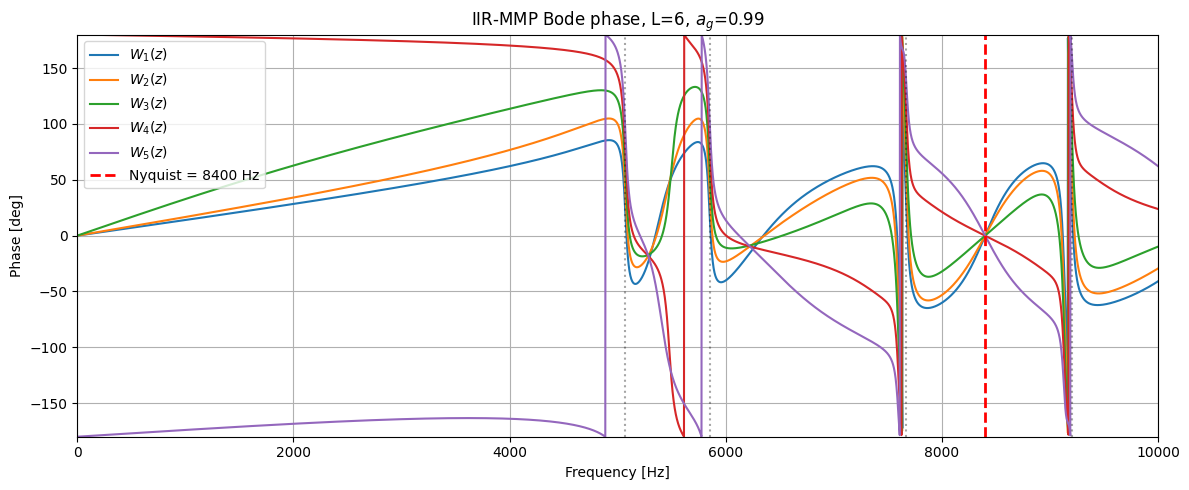

In [25]:
# Q filter bode plot MMP to show the notches
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from mfmdob_functions import mmp_coeff

Ts_fast = plant.Ts / plant.Mr_f
fs_fast = 1 / Ts_fast

L = 6
a_g = 0.99
Ts_slow = L * Ts_fast
fs_slow = 1 / Ts_slow
f_nyq = fs_slow / 2

f_hz = np.array([5072, 5850, 7670, 9200])

w_kiir, Bpara = mmp_coeff(f_hz=f_hz, t_fs=Ts_fast, a_g=a_g, L=L)

f_plot = np.linspace(1, 10000, 5000)
omega = 2 * np.pi * f_plot * Ts_slow

plt.figure(figsize=(12,5))

for k in range(w_kiir.shape[1]):
    b = w_kiir[:, k]
    a = Bpara

    _, H = signal.freqz(b, a, worN=omega)

    mag_db = 20*np.log10(np.abs(H))

    plt.plot(f_plot, mag_db, label=f'$W_{k+1}(z)$')

for fd in f_hz:
    plt.axvline(fd, color='k', linestyle=':', alpha=0.35)
    plt.text(fd, 0.02, f'{fd}', rotation=90,
             transform=plt.gca().get_xaxis_transform(),
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.axvline(f_nyq, color='r', linestyle='--', linewidth=2,
            label=f'Nyquist = {f_nyq:.0f} Hz')

plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title(f'IIR-MMP Bode magnitude, L={L}, $a_g$={a_g}')
plt.xlim([0, 10000])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

for k in range(w_kiir.shape[1]):
    b = w_kiir[:, k]
    a = Bpara

    _, H = signal.freqz(b, a, worN=omega)

    # Wrapped phase in [-180, 180)
    phase_deg = np.angle(H, deg=True)
    phase_deg = (phase_deg + 180) % 360 - 180

    plt.plot(f_plot, phase_deg, label=f'$W_{k+1}(z)$')

for fd in f_hz:
    plt.axvline(fd, color='k', linestyle=':', alpha=0.35)

plt.axvline(
    f_nyq,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f'Nyquist = {f_nyq:.0f} Hz'
)

plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [deg]')
plt.title(f'IIR-MMP Bode phase, L={L}, $a_g$={a_g}')
plt.xlim([0, 10000])
plt.ylim([-180, 180])
plt.legend()
plt.tight_layout()
plt.show()